In [1]:
%pip -q install lightgbm

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv('train_videos.csv')
test = pd.read_csv('test_videos.csv')
creators = pd.read_csv('creators_daily.csv')
engagement = pd.read_csv('engagement_daily.csv')
sample = pd.read_csv('sample_submission.csv')

print("Train:", train.shape)
print("Test:", test.shape)
print("Creators:", creators.shape)
print("Engagement:", engagement.shape)

Train: (12000, 27)
Test: (3001, 26)
Creators: (252166, 7)
Engagement: (79489, 10)


In [3]:
train.head()

,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,...,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear,target_day30_views
0,7389777708642798891,6823500943611528198,2024-07-09 18:11:50,2024-07-09,61.230,540p,en,1,0.0,0,...,4.0,6.532745,Lifestyle,0.003960,0.790962,0.017963,0.002873,0.004761,0.001092,1371
1,7414315783221693739,6851716737763886085,2024-09-13 21:12:02,2024-09-13,58.095,540p,en,1,0.0,0,...,6.0,4.148378,Beauty_Fashion,0.004058,0.767556,0.003882,0.012160,0.019463,0.001298,1184
2,7408397785503943942,6809119722295968773,2024-08-28 22:27:16,2024-08-28,7.431,720p,en,1,0.0,0,...,4.0,0.000000,Life_hacks_Personal_growth,0.003275,0.849156,0.003241,0.007868,0.005667,0.003849,638
3,7406460852611681567,6790225026127627269,2024-08-23 17:11:01,2024-08-23,15.046,540p,un,0,0.0,0,...,0.0,0.000000,Beauty_Fashion,0.004971,0.612373,0.006764,0.010911,0.066338,0.001878,312
4,7428770082219756831,2033984,2024-10-22 20:02:15,2024-10-22,7.895,540p,en,1,0.0,0,...,NaN,NaN,Beauty_Fashion,0.022163,0.006064,0.008672,0.041306,0.474281,0.022709,180


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   video_id             12000 non-null  int64  
 1   author_id            12000 non-null  int64  
 2   create_time          12000 non-null  object 
 3   create_date          12000 non-null  object 
 4   duration             12000 non-null  float64
 5   ratio                12000 non-null  object 
 6   desc_language        12000 non-null  object 
 7   is_english           12000 non-null  int64  
 8   created_by_ai        12000 non-null  float64
 9   is_ads               12000 non-null  int64  
 10  music_selected_from  11879 non-null  object 
 11  music_author         11979 non-null  object 
 12  music_owner_id       9028 non-null   float64
 13  music_id             11999 non-null  float64
 14  word_count           7953 non-null   float64
 15  emoji_count          7953 non-null  

In [5]:
train.isna().mean().sort_values(ascending=False).head(15)

,0
question_count,0.337250
hashtag_count,0.337250
word_count,0.337250
emoji_count,0.337250
speaking_rate,0.337250
music_owner_id,0.247667
music_selected_from,0.010083
anger,0.003500
joy,0.003500
disgust,0.003500


In [6]:
train['target_day30_views'].describe( percentiles=[.5,.9,.95,.99,.995,.999])

,target_day30_views
count,1.200000e+04
mean,2.922860e+04
std,2.752131e+05
min,0.000000e+00
50%,6.680000e+02
90%,2.172980e+04
95%,6.967635e+04
99%,5.440549e+05
99.5%,1.093135e+06
99.9%,4.398993e+06


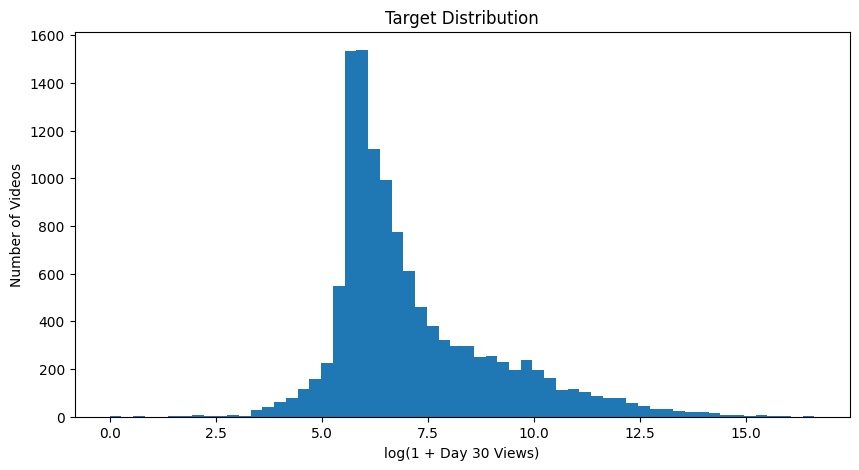

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(np.log1p(train['target_day30_views']), bins=60)
plt.xlabel('log(1 + Day 30 Views)')
plt.ylabel('Number of Videos')
plt.title('Target Distribution')
plt.show()

In [8]:
engagement.groupby('video_id')['days_since_post'].count().describe()

,days_since_post
count,15000.000000
mean,5.299267
std,0.551356
min,1.000000
25%,5.000000
50%,5.000000
75%,6.000000
max,6.000000


In [9]:
engagement['days_since_post'].value_counts().sort_index()

,count
days_since_post,
0,5638
1,14750
2,14726
3,14768
4,14856
5,14751


In [10]:
import numpy as np, pandas as pd, warnings
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
from sklearn.model_selection import RepeatedKFold
warnings.filterwarnings('ignore')
SEED = 42

mets = ['play_count', 'like_count', 'comment_count', 'share_count','collect_count', 'download_count', 'whatsapp_share_count']
short = dict(zip(mets, ['play', 'like', 'comm', 'share', 'coll', 'dl', 'wa']))

eng = engagement[engagement.days_since_post.between(0,5)].drop_duplicates(['video_id', 'days_since_post'], keep='last')
wide = eng.pivot(index='video_id', columns='days_since_post', values=mets)

parts = {}
for m in mets :
  w = wide[m].reindex(columns=range(6)).ffill(axis=1).fillna(0)
  for d in range(6):
    parts[f'{short[m]}_d{d}'] = w[d]
E = pd.DataFrame(parts).reset_index()

df = pd.concat([train.assign(is_train=1),
      test.assign(is_train=0, target_day30_views=np.nan)], ignore_index=True )

df = df.merge(E, on='video_id', how= 'left')
ecols = [c for c in E.columns if c!= 'video_id']
df[ecols] = df[ecols].fillna(0)
print (df.shape)

(15001, 70)


In [11]:
for d in range(0,6):
  df[f'lp{d}'] = np.log1p(df[f'play_d{d}'])

for m in ['like', 'comm', 'share', 'coll', 'dl', 'wa']:
  df[f'{m}_rate5'] = df[f'{m}_d5'] / (df.play_d5 + 1)

for a, b in [(5,4), (5,3), (5,2), (5,1)] :
    df [f'growth_{a}_{b}'] = (df[f'play_d{a}'] +1) / (df[f'play_d{b}'] + 1)

for d in range(1,6) :
      prev = df[f'play_d{d-1}'].where(df[f'play_d{d-1}'] > 0,0)
      df[f'inc{d}'] = (df[f'play_d{d}'] - prev).clip(lower=0)

df['inc5_over_p5'] = df.inc5 / (df.play_d5 +1)
df['inc4_over_p4'] = df.inc4 / (df.play_d4 +1)
df['slope_log'] = (df.lp5 - df.lp1)/ 4
df['engage_rate5'] = (df.like_d5 + df.comm_d5 +df.share_d5 +df.coll_d5) / (df.play_d5 + 1)
df['share_to_like'] = df.share_d5 / (df.like_d5 + 1)
df['has_d0'] = (df.play_d0 > 0).astype(int)

print(df.shape)

(15001, 97)


In [12]:
cre = creators.copy()
cre['date'] = pd.to_datetime(cre['date'])
df['create_date'] = pd.to_datetime(df['create_date'])
df['create_time'] = pd.to_datetime(df['create_time'])
cre = cre.sort_values('date')
cols = ['follower_count', 'following_count', 'total_favorited', 'video_count', 'enterprise_verified']

left = df[['video_id', 'author_id', 'create_date']].sort_values('create_date')
at0 = pd.merge_asof(left, cre, left_on='create_date', right_on='date', by='author_id', direction='backward')
at0 = at0.set_index('video_id')[cols].add_suffix('_at0')

left5 = left.assign(d5=left.create_date + pd.Timedelta(days=5)).sort_values('d5') # until day 5 only
at5 = pd.merge_asof(left5, cre, left_on='d5', right_on='date', by='author_id', direction='backward')
at5 = at5.set_index('video_id')[['follower_count','total_favorited', 'video_count']].add_suffix('_at5')

df = df.merge(at0, left_on='video_id', right_index=True, how='left') \
.merge(at5, left_on='video_id', right_index=True, how='left')

df['follower_gain5'] = df.follower_count_at5 - df.follower_count_at0
df['fav_per_video'] = df.total_favorited_at0 / (df.video_count_at0 + 1)
df['play5_per_follower'] = df.play_d5 / (df.follower_count_at0 + 1)
df['log_follow'] = np.log1p(df.follower_count_at0)

df['hour'] = df.create_time.dt.hour
df['dow'] = df.create_time.dt.dayofweek
df['day_index'] = (df.create_date - df.create_date.min()).dt.days
df['topic_cat'] = df ['topic'].astype('category').cat.codes
print(df.shape)

(15001, 113)


In [13]:
FEATS = ['growth_5_4', 'growth_5_3', 'growth_5_1', 'inc5_over_p5', 'inc4_over_p4', 'lp5', 'lp1',
         'like_rate5', 'share_rate5', 'coll_rate5', 'comm_rate5', 'engage_rate5', 'has_d0',
         'log_follow', 'play5_per_follower', 'fav_per_video', 'day_index', 'topic_cat', 'hour']

X_all = df[FEATS].fillna(0).astype(float).values
lo, hi = np.percentile(X_all, 1, axis=0), np.percentile(X_all, 99, axis=0)
Xs_all = np.clip(X_all, lo, hi)
Xs_all = (Xs_all - Xs_all.mean(0)) / (Xs_all.std(0) + 1e-9)

is_tr = (df.is_train == 1).values
Xr_tr, Xr_te = X_all[is_tr], X_all[~is_tr]
Xs_tr, Xs_te = Xs_all[is_tr], Xs_all[~is_tr]
y = df.loc[is_tr, 'target_day30_views'].values.astype(float)
p5_tr = df.loc[is_tr, 'play_d5'].values.astype(float)
p5_te = df.loc[~is_tr, 'play_d5'].values.astype(float)

print (Xr_tr.shape, Xr_te.shape)


(12000, 19) (3001, 19)


In [28]:
CLIP =  4.0

def fit_predict(Xs_a, Xr_a, y_a, p5_a, Xs_b, Xr_b, p5_b):
  b_a, b_b = p5_a + 1, p5_b +1
  base = p5_b * (y_a.sum() / p5_a.sum())

  r= np.clip(y_a / b_a, 0.5, CLIP)
  ridge = Ridge(alpha=200).fit(Xs_a, r, sample_weight=b_a)
  p_ridge = b_b * np.clip(ridge.predict(Xs_b), 1.0, CLIP)

  lr = np.log1p(y_a) - np.log(b_a)
  gb = HGB(max_iter=200, learning_rate=0.03, max_leaf_nodes=6, min_samples_leaf=60,
         l2_regularization=10, random_state=SEED).fit(Xr_a, lr, sample_weight=np.sqrt(b_a))
  tr_pred = b_a * np.exp(gb.predict(Xr_a))
  c2 = (y_a * tr_pred).sum() / (tr_pred ** 2).sum()
  p_gb = 0.5 * (c2 * b_b * np.exp(gb.predict(Xr_b))) + 0.5 * base

  return {'baseline': base , 'ridge': p_ridge, 'gboost': p_gb, 'blend' : (base + p_ridge + p_gb) / 3}


rmse = lambda a, b : float(np.sqrt(np.mean((a-b) ** 2)))
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)
scores = {k: [] for k in ['baseline', 'ridge', 'gboost', 'blend']}
for tri, vai in rkf.split(Xr_tr):
  preds = fit_predict(Xs_tr[tri], Xr_tr[tri], y[tri], p5_tr[tri], Xs_tr[vai], Xr_tr[vai], p5_tr[vai])
  for k, p in preds.items():
   scores[k].append(rmse(y[vai], np.maximum(p, 0)))

print(f'CV RMSE:')
for k, v in scores.items():
 print (f' {k:9s} {np.mean(v):>10,.0f}  +/- {np.std(v):,.0f}')


CV RMSE:
 baseline      72,753  +/- 20,177
 ridge         61,930  +/- 17,345
 gboost        65,183  +/- 11,919
 blend         63,188  +/- 12,049


In [29]:
final = fit_predict(Xs_tr,Xr_tr, y, p5_tr, Xs_te,Xr_te, p5_te)['blend']
final = np.maximum(final, p5_te)

pred = pd.DataFrame({'video_id': df.loc[~is_tr, 'video_id'].values,
                     'target_day30_views': np.round(final).astype(np.int64)})
submission = sample[['video_id']].merge(pred, on = 'video_id', how='left')
assert submission.target_day30_views.notna().all() and len(submission) == len(sample)
submission.to_csv('submission.csv', index= False)
print(submission.head(), '\n', submission.shape)

from google.colab import files
files.download('submission.csv')

              video_id  target_day30_views
0  7400582591771938090                 309
1  7403167206978374958                 455
2  7435124823820356906                2496
3  7409800970143714606                 354
4  7410935177553333550                 332 
 (3001, 2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>